In [ ]:
import jax
import equinox as eqx
import numpy as np
import jax.numpy as jnp
import immrax as irx
import matplotlib.pyplot as plt
import scipy
from immutabledict import immutabledict
from reach import *
from functools import partial

# Some configurations
jax.config.update("jax_enable_x64", True)

# We wrap the jax.jit function to set the backend to cpu by default for convenience.
device = 'cpu'
def jit (*args, **kwargs):
    kwargs.setdefault('backend', device)
    return jax.jit(*args, **kwargs)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 14
})

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
class PlanarMultirotor (irx.System) :
    def __init__ (self) :
        self.xlen = 5
        self.evolution = 'continuous'

    def f(self, t, x, u):
        x, y, vx, vy, theta = x.ravel()
        u1, u2 = u.ravel()
        g = 9.81

        return jnp.array([
            vx,
            vy,
            -1*u1*jnp.sin(theta),
            u1*jnp.cos(theta) - g,
            u2
        ])

sys = PlanarMultirotor()

In [8]:
# Initial set
# P0 = jnp.array([[ 8.31293757e-06, -2.89737472e-19, -4.15657084e-04 , 6.42985332e-18,
#   -7.18075746e-07],
#  [-2.89737472e-19  ,7.99047747e-02,  8.25440432e-17 ,-3.99523874e+00,
#    7.32338790e-13],
#  [-4.15657084e-04 , 8.25440432e-17 , 4.15657049e-02 ,-4.31924960e-15,
#    2.87276688e-04],
#  [ 6.42985332e-18 ,-3.99523874e+00, -4.31924960e-15,  3.99523882e+02,
#   -3.90542562e-11],
#  [-7.18075746e-07,  7.32338790e-13 , 2.87276688e-04, -3.90542562e-11,
#    9.99999999e+03]])
P0 = jnp.array([[1.4518 ,  -0.0000 ,   0.5538  , -0.0000 ,  -1.0000],
   [-0.0000  ,  1.7321 ,   0.0000  ,  1.0000 ,  -0.0000],
    [0.5538  ,  0.0000  ,  0.7019  , -0.0000 ,  -1.4518],
   [-0.0000 ,   1.0000  , -0.0000 ,   1.7321 ,   0.0000],
   [-1.0000 ,  -0.0000  , -1.4518  ,  0.0000  ,  5.4272]])
                    #    [0.0280, 0.9537, 0.0151, 2.2845]]) / jnp.array((0.01)**2)
P0 = scipy.linalg.sqrtm(P0)
print(P0)
x0 = jnp.array([1.505,1.505,0.005,0.005,0.0])
e0 = Ellipsoid(P0, x0)
ix0 = iover(e0)

# ix0 = irx.interval([1.50,1.50,0.00,0.00,0.0], [1.505,1.505,0.005,0.005,0.005])
# P0 = eover(ix0, jnp.eye(5))

t0 = 0.     # Initial time
dt = 0.001  # Time step
# T = 3.      # Horizon for one step of the algorithm
# N = 5       # Number of iterations of the algorithm

T = 2.      # Horizon for one step of the algorithm
N = 5       # Number of iterations of the algorithm
tf = T*N    # Final time

sys_mjacM = irx.mjacM(sys.f)
sys_jacM = irx.jacM(sys.f)

perm = irx.Permutation((0, 6, 7, 1, 2, 3, 4, 5))

print(ix0)

[[ 1.15212457e+00  2.69029811e-17  2.39229205e-01 -8.64978157e-18
  -2.59187882e-01]
 [ 4.64690832e-18  1.25426748e+00 -9.21166786e-17  3.98639053e-01
   3.77394905e-17]
 [ 2.39229205e-01 -6.65376230e-17  6.45541191e-01  8.01961117e-17
  -4.77436863e-01]
 [ 0.00000000e+00  3.98639053e-01  3.42807320e-17  1.25426748e+00
   0.00000000e+00]
 [-2.59187882e-01  2.54678464e-16 -4.77436863e-01 -3.69741840e-18
   2.26540850e+00]]
[[( 0.5336826 , 2.4763174 )]
 [( 0.56326582, 2.44673418)]
 [(-1.38906142, 1.39906142)]
 [(-0.93673418, 0.94673418)]
 [(-0.72434526, 0.72434526)]]


In [4]:

@partial(jit, static_argnames=('mjacM',))
def rollout (ix, xc, mjacM=True) :
    def step (carry, t) :
        xtut, xnomt, M, uM = carry
        unomt = jnp.array([9.81, 0])
        uint = irx.icentpert(unomt, 0.0001)
        if mjacM :
            Mt, Mx, Mu = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), uint,
                                centers=((jnp.array([0.]), xnomt, unomt),), 
                                permutations=(perm,))[0]
        else :
            # Mt, Mx = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), 
            #                     centers=((jnp.array([0.]), xnomt),), 
            #                     permutations=(perm,))[0]
            # _Mt, _Mx = sys_jacM(irx.interval(0.), irx.ut2i(xtut))
            Mt, Mx, Mu = sys_jacM(irx.interval(0.), irx.ut2i(xtut), uint)
        F = lambda t, x, u : Mx@(x - xnomt) + Mu@(u - unomt) + sys.f(0., xnomt, unomt) 
        # F = irx.natif(sys.f)
        embsys = irx.ifemb(sys, F)
        xnomtp1 = xnomt + dt*sys.f(0., xnomt, unomt)
        xtutp1 = xtut + dt*embsys.E(irx.interval(0.), xtut, uint)
        return ((xtutp1, xnomtp1, M|Mx, uM|Mu), (xtutp1, xnomtp1))
    
    tt = jnp.arange(0, T, dt)
    J0 = jax.jacfwd(sys.f, argnums=(1,))(0., xc, jnp.array([9.81, 0.]))[0]
    Ju = jax.jacfwd(sys.f, argnums=(2,))(0., xc, jnp.array([9.81, 0.]))[0]
    carry, xx = jax.lax.scan(step, (irx.i2ut(ix), xc, irx.interval(J0), irx.interval(Ju)), tt)
    return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), carry[2], carry[3]

@jit
def rollout_undisturbed (xc) :
    def step (carry, t) :
        xnomt = carry
        unomt = jnp.array([9.81, -1*xnomt[-1]])
        fc = sys.f(0., xnomt, unomt)
        xnomtp1 = xnomt + dt*fc
        return (xnomtp1, xnomtp1)

    tt = jnp.arange(0, tf, dt)
    carry, xx = jax.lax.scan(step, xc, tt)

    return jnp.vstack((xc, xx))

xx, xxnom, M, Mu = rollout(ix0, x0)
print(M)
print(Mu)

_, _, _M, _Mu = rollout(ix0, x0, False)
# print(_M)
# print(_Mu)

[[[( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 1.        ,  1.        )]
  [( 0.        ,  0.        )]
  [( 0.        ,  0.        )]]

 [[( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 1.        ,  1.        )]
  [( 0.        ,  0.        )]]

 [[(-0.        , -0.        )]
  [(-0.        , -0.        )]
  [(-0.        , -0.        )]
  [(-0.        , -0.        )]
  [(-9.8101    , -7.34566261)]]

 [[(-0.        , -0.        )]
  [(-0.        , -0.        )]
  [(-0.        , -0.        )]
  [(-0.        , -0.        )]
  [(-6.50208448,  6.50208448)]]

 [[( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 0.        ,  0.        )]
  [( 0.        ,  0.        )]]]
[[[( 0.,  0.)]
  [( 0.,  0.)]]

 [[( 0.,  0.)]
  [( 0.,  0.)]]

 [[(-0., -0.)]
  [(-0., -0.)]]

 [[( 1.,  1.)]
  [( 0.,  0.)]]

 [[( 0.,  0.)]
  [( 1.,  1.)]]]


In [5]:
# Jitted get_sparse_corners since corner locations don't change.
from itertools import product
sh_x = M.shape
ic_x = jnp.isclose(M.lower.reshape(-1), M.upper.reshape(-1))
cs_x = [irx.Corner(p) for p in product(*[(0,) if ic_x[i] else (0,1) for i in range(len(ic_x))])]

@jit
def gsc_x (M) :
    M = M.reshape(-1)
    return [jnp.array([M.lower[i] if ci == 0 else M.upper[i] for i, ci in enumerate(c)]).reshape(sh_x) for c in cs_x]


sh_u = Mu.shape
ic_u = jnp.isclose(Mu.lower.reshape(-1), Mu.upper.reshape(-1))
cs_u = [irx.Corner(p) for p in product(*[(0,) if ic_u[i] else (0,1) for i in range(len(ic_u))])]
@jit
def gsc_u (Mu) :
    Mu = Mu.reshape(-1)
    return [jnp.array([Mu.lower[i] if ci == 0 else Mu.upper[i] for i, ci in enumerate(c)]).reshape(sh_u) for c in cs_u]

M_c = gsc_x(M)
Mu_c = gsc_u(Mu)

# Expecting 2^6 = 64 corners since 6 nonconstant elements in Jacobian matrix
print(f'{len(M_c)} corners')
print(f'{len(Mu_c)} corners')

4 corners
1 corners


i=0
(5, 2)
optimal: -0.8560499999999991
[[ 5.21461435e-01 -1.50272720e-19  4.03661228e-01 -3.12009068e-19
  -5.17876328e-01]
 [-1.50272720e-19  2.98349192e-03 -2.88063681e-19  2.59850746e-03
   2.72105037e-19]
 [ 4.03661228e-01 -2.88063681e-19  4.80039162e-01 -4.00605056e-19
  -6.30725103e-01]
 [-3.12009068e-19  2.59850746e-03 -4.00605056e-19  3.03546252e-03
   4.46664664e-19]
 [-5.17876328e-01  2.72105037e-19 -6.30725103e-01  4.46664664e-19
   1.76197021e+00]]
[[( -2.34494779,  2.34494779)]
 [(-36.29674881, 36.29674881)]
 [( -2.82586977,  2.82586977)]
 [(-35.98468634, 35.98468634)]
 [( -1.03561597,  1.03561597)]]
i=1
(5, 2)
optimal: -0.8560499999999998
[[ 2.88920104e+00  5.49010021e-20  2.23651905e+00  2.76837157e-20
  -2.86933739e+00]
 [ 5.49010021e-20  1.65302877e-02  1.26113704e-19  1.43972485e-02
  -3.66859770e-20]
 [ 2.23651905e+00  1.26113704e-19  2.65969733e+00  1.72476691e-20
  -3.49458550e+00]
 [ 2.76837157e-20  1.43972485e-02  1.72476691e-20  1.68182366e-02
  -2.62821864e-21

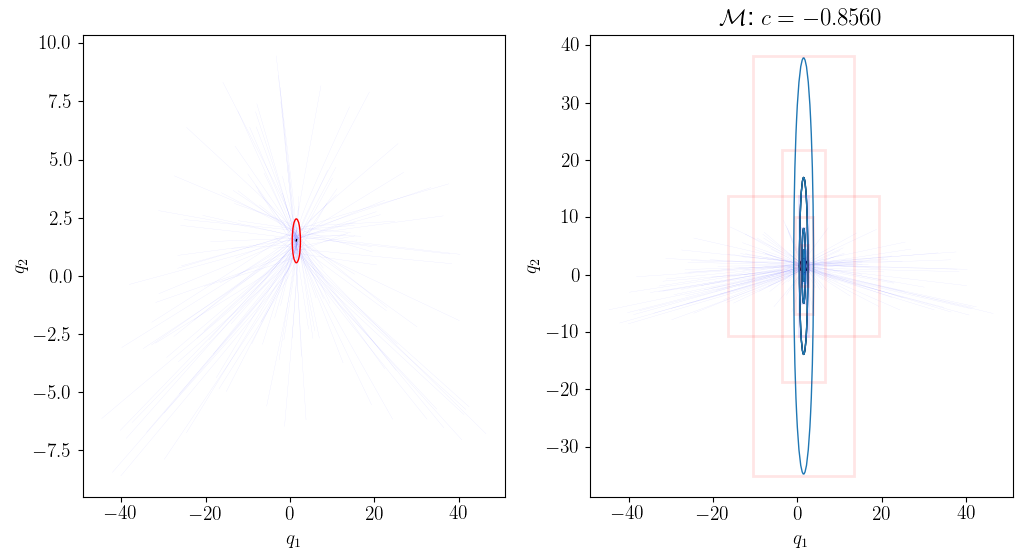

In [9]:
# %matplotlib ipympl

# fig, axs = plt.subplots(1,3,figsize=(10, 3))
fig, axs = plt.subplots(1,2,figsize=(12, 6))

from math import floor
mc_N = 1000
mc_x0s = jnp.vstack((irx.utils.gen_ics(ix0, mc_N), x0))
mc_tf = T*N
mc_dt = dt
mc_T = floor(mc_tf/mc_dt)
mc_trajs = jax.vmap(rollout_undisturbed)(mc_x0s)

for ax in axs[:2] :
    for i in range(mc_N) :
        if e0.V(mc_trajs[i, 0]) <= 1. :
            ax.plot(mc_trajs[i, :mc_T, 0], mc_trajs[i, :mc_T, 1], 'b', alpha=0.1, zorder=-1, lw=0.2)
    ax.plot(mc_trajs[mc_N, :mc_T, 0], mc_trajs[mc_N, :mc_T, 1], 'black', alpha=1, zorder=-1, lw=1)

    e0.plot_projection(ax, 0, 1, color='red')

# axs[2].scatter(mc_trajs[:mc_N, -1, 0], mc_trajs[:mc_N, -1, 1], c='b', s=1, alpha=0.1)
# axs[2].scatter(mc_trajs[mc_N, -1, 0], mc_trajs[mc_N, -1, 1], c='r', s=1, alpha=0.5)
K = -1*jnp.array([[-0.0000 ,   1.0000 ,  -0.0000  ,  1.7321 ,  -0.0000], [-1.0000 ,  -0.0000 ,  -1.4518  , -0.0000  ,  5.4272]])

def reach_P_contraction (rollout, e0:Ellipsoid, i0:irx.Interval, ax, T:float, N:int, dt:float, mjacM=True) :
    """
    For now, rollout is a function that takes x0 (interval) and returns xx, xnom, M.
    """

    ee = [e0]
    ii = [i0]

    for i in range(N) :
        ixT = ii[-1]
        ei = ee[i]
        P1 = np.array(ei.P)

        ix0 = iover(ei) & ixT
        xnom0 = ei.xc
        xx, xnom, M, Mu = rollout(ix0, xnom0, mjacM)
        ixT = irx.ut2i(xx[-1])
        ii.append(ixT)
        ulx, olx = irx.i2lu(ix0 - xnom[0])
        M_c = gsc_x(M)
        Mu_c = gsc_u(Mu)
        prevc = jnp.max(jnp.real(jnp.array([jnp.linalg.eigvals(Mi+Miu@K) for Mi in M_c for Miu in Mu_c]))) 
        # print(prevc)

        print(f'{i=}')
        # Prepare SDP for line search over c
        c = cp.Parameter()

        P2 = cp.Variable((5,5), PSD=True)
        # P2 = P1
        Gam = cp.Variable(5, nonneg=True)
        tau = cp.Variable(1, nonneg=True)
        dGam = cp.diag(Gam)
        
        cons = []
        cons.append(P2 << P1)
        # cons.extend([M.T @ P2 + P2 @ M << 2*c*P2 for M in M_c])
        print(Mu.shape)
        cons.extend([(Mx_c + Mu_d@K).T @ P2 + P2 @ (Mx_c + Mu_d@K) << 2*c*P2 for Mu_d in Mu_c for Mx_c in M_c])
        prob = cp.Problem(cp.Maximize(cp.log_det(P2)), cons)
        # prob = cp.Problem(cp.Minimize(c), cons)
        c.value = np.asarray(prevc)

        ei.plot_projection(ax)
        irx.utils.draw_iarray(ax, ix0, alpha=0.1, ec='blue')
        irx.utils.draw_iarray(ax, ixT, alpha=0.1, ec='red')
        # prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)
        # print(f'{prob.status}: {c.value}')
        j = 0
        while prob.status != 'optimal' and j < 1000:
            # c.value = c.value + 0.0025
            j += 1
            c.value = c.value + 0.01
            print(f'Trying c={c.value:.4f}', end='\r')
            try :
                # prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10})
                prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)
            except KeyboardInterrupt :
                raise KeyboardInterrupt
            except :
                pass

        print(f'{prob.status}: {c.value}')

        # pretitle = 'mjacM' if mjacM else 'jacM'
        pretitle = '$\\mathcal{M}$' if mjacM else '$\\mathcal{J}$'
        color = 'tab:blue' if mjacM else 'tab:orange'

        Ellipsoid(P2.value, xnom0).plot_projection(ax, color='tab:blue')
        Ellipsoid(P2.value*np.exp(-c.value*T), xnom[-1]).plot_projection(ax, color='tab:blue')
        # Ellipsoid(P2.value*np.exp(-c.value*T), xnom[-1]).plot_projection(axs[2], rescale=True, color=color, label=pretitle)
        print(P2.value)
        print(iover(Ellipsoid(P2.value)))
        ax.set_title(pretitle + f': $c = {c.value:.4f}$')

        ee.append(Ellipsoid(P2.value*np.exp(-c.value*T), xnom[-1]))

# reach_P_contraction(rollout, e0, ix0, axs[0], T, N, dt, False)
reach_P_contraction(rollout, e0, ix0, axs[1], T, N, dt, True)
axs[0].set_xlabel('$q_1$'); axs[0].set_ylabel('$q_2$')
axs[1].set_xlabel('$q_1$'); axs[1].set_ylabel('$q_2$')
# axs[2].legend()

# fig.tight_layout()
# fig.savefig('RobotArm.pdf')
plt.show()


In [7]:
def reach_K_contraction (rollout, e0:Ellipsoid, i0:irx.Interval, ax, T:float, N:int, dt:float, mjacM=True) :
    """
    For now, rollout is a function that takes x0 (interval) and returns xx, xnom, M.
    """

    ee = [e0]
    ii = [i0]

    for i in range(N) :
        ixT = ii[-1]
        ei = ee[i]
        P1 = np.array(ei.P)

        ix0 = iover(ei) & ixT
        xnom0 = ei.xc
        xx, xnom, M, Mu = rollout(ix0, xnom0, mjacM)
        ixT = irx.ut2i(xx[-1])
        ii.append(ixT)
        ulx, olx = irx.i2lu(ix0 - xnom[0])
        M_c = gsc_x(M)
        Mu_c = gsc_u(Mu)
        # prevc = jnp.max(jnp.real(jnp.array([jnp.linalg.eigvals(Mi+Miu@K) for Mi in M_c for Miu in Mu_c]))) 
        prevc = -100.
        print(prevc)

        print(f'{i=}')
        # Prepare SDP for line search over c
        c = cp.Variable()

        # P2 = cp.Variable((5,5), PSD=True)
        Gam = cp.Variable(5, nonneg=True)
        tau = cp.Variable(1, nonneg=True)
        dGam = cp.diag(Gam)
        K = cp.Variable((2,5))  # Control gain matrix
        K_0 = jnp.array([[-0.0000 ,   1.0000 ,  -0.0000  ,  1.7321 ,  -0.0000], [-1.0000 ,  -0.0000 ,  -1.4518  , -0.0000  ,  5.4272]])
        
        cons = []
        # cons.extend([M.T @ P2 + P2 @ M << 2*c*P2 for M in M_c])
        print(Mu.shape)
        cons.extend([(Mx_c + Mu_d@K).T @ P0 + P0 @ (Mx_c + Mu_d@K) << 2*c*P0 for Mu_d in Mu_c for Mx_c in M_c])
        prob = cp.Problem(cp.Minimize(c + jnp.sum(jnp.abs(K - K_0))), cons)

        c.value = np.asarray(prevc)

        ei.plot_projection(ax)
        irx.utils.draw_iarray(ax, ix0, alpha=0.1, ec='blue')
        irx.utils.draw_iarray(ax, ixT, alpha=0.1, ec='red')

        prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=True)
        # j = 0
        # while prob.status != 'optimal' and j < 1000:
        #     # c.value = c.value + 0.0025
        #     j += 1
        #     c.value = c.value + 0.01
        #     print(f'Trying c={c.value:.4f}', end='\r')
        #     try :
        #         # prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10})
        #         prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)
        #     except KeyboardInterrupt :
        #         raise KeyboardInterrupt
        #     except :
        #         pass

        print(f'{prob.status}: {c.value}')
        print(K.value)
        # pretitle = 'mjacM' if mjacM else 'jacM'
        pretitle = '$\\mathcal{M}$' if mjacM else '$\\mathcal{J}$'
        color = 'tab:blue' if mjacM else 'tab:orange'

        Ellipsoid(P0, xnom0).plot_projection(ax, color='tab:blue')
        Ellipsoid(P0*np.exp(-c.value*T), xnom[-1]).plot_projection(ax, color='tab:blue')
        # Ellipsoid(P2.value*np.exp(-c.value*T), xnom[-1]).plot_projection(axs[2], rescale=True, color=color, label=pretitle)
        # print(P0)
        ax.set_title(pretitle + f': $c = {c.value:.4f}$')

reach_K_contraction(rollout, e0, ix0, axs[1], T, 1, dt, True)

-100.0
i=0
(5, 2)


TypeError: Cannot interpret value of type <class 'cvxpy.atoms.affine.add_expr.AddExpression'> as an abstract array; it does not have a dtype attribute